**09 텍스트를 위한 인공 신경망**
====

**09-3 LSTM과 GRU 셀**
----

**LSTM, GRU 층**      
SimpleRNN층 보다 계산이 훨씬 복잡     
성능이 뛰어나서 순환 신경망에서 많이 사용      

일반적으로 기본 순환층은 긴 시퀀스를 학습하기 어려움     
-> 시퀀스가 길수록 순환되는 은닉 상태에 담긴 정보가 희석      
-> 멀리 떨어져 있는 단어 정보를 인식하는데 어려움     
-> **LSTM, GRU 층**이 해결      

**LSTM Long Short-Term Memory 모델**      
단기 기억을 오래 기억하기 위해 고안된 모델    

- **cell state**     
: 기억 저장 공간을 따로 만들어서 **어떤 정보는 보관, 어떤 건 버리기** 하면서 전달하는 구조      

    **Forget Gate** : 무엇을 잊을지, 남겨둘지     
    **Input Gate** : 무엇을 새로 저장할지     
        입력값 중 중요한 의미만 골라서    
        기존 셀 상태에 더함       
    **Cell state Update** : Forget Gate + Input Gate 합쳐져서 새로운 "메모리"가 완성     
    **Output Gate (최종 출력)**: 어떤 정보를 출력할지      
        이 시점에서 hidden state가 만들어짐    

**1. Forget Gate**
- sigmoid 함수 사용 : 0~1로 압축함 ex) 0.64 = 64 % 만 기억하고 나머지는 버리기     
- h_{t-1}과 x_t를 받아서 0~1 사이의 값을 C_{t-1}에 보내줌 = **f_t**     
- f_t = sig(W_f * [h_{t-1}, x_t] + b_f) 

**2. Input Gate**        
- sigmoid layer : h_{t-1}과 x_t를 받아서 0~1 사이의 값으로 바꿈     
                    어떤 값을 업데이트 할지 정함 = **i_t**        
- **i_t** = sig(W_i * [h_{t-1}, x_t] + b_i         
- tanh layer : 새로운 후보 값들인 **tilde{C}_t** 라는 벡터를 만듦      
- **tilde{C}_t** = tanh(W_c * [h_{t-1}, x_t] + b_c)  
- 두 layer에서 나온 정보를 합친다                 

**3. Cell state Update**        
- **C_t** = f_t * C_{t-1} + i_t * tilde{C}_t        

**4. Output Gate**      
- o_t = sig(W_o * [h_{t-1}, x_t] + b_o)
- **h_t** = o_t * tanh(C_t)      
- tanh(C_t)의 필요한 일부만 tanh layer에 태움    

In [13]:
# LSTM 신경망 모델 

# IMDB dataset 준비

from keras.datasets import imdb
from sklearn.model_selection import train_test_split

(train_input, train_target), (test_input, test_target) = imdb.load_data(num_words=500)
train_input, val_input, train_target, val_target = train_test_split(train_input, train_target, test_size=0.2, random_state=42)

In [14]:
# 샘플의 길이 100으로 맞추기

from keras.preprocessing.sequence import pad_sequences

train_seq = pad_sequences(train_input, maxlen=100)
val_seq = pad_sequences(val_input, maxlen=100)

In [15]:
# LSTM 모델 만들기

import keras

model_lstm = keras.Sequential()
model_lstm.add(keras.layers.Input(shape=(100,)))
model_lstm.add(keras.layers.Embedding(500, 16))
model_lstm.add(keras.layers.LSTM(8))
model_lstm.add(keras.layers.Dense(1, activation='sigmoid'))

In [16]:
model_lstm.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 8)              │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,809 (34.41 KB)

 Trainable params: 8,809 (34.41 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# LSTM 모델 훈련하기  

model_lstm.compile(optimizer='adam', loss='binary_crossentropy',metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-lstm-model.keras',save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
history=model_lstm.fit(train_seq, train_target, epochs=100, batch_size=64, validation_data=(val_seq, val_target), callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.6188 - loss: 0.6493 - val_accuracy: 0.7760 - val_loss: 0.4974
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.7779 - loss: 0.4794 - val_accuracy: 0.7902 - val_loss: 0.4520
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.7961 - loss: 0.4416 - val_accuracy: 0.7986 - val_loss: 0.4338
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.8078 - loss: 0.4204 - val_accuracy: 0.7636 - val_loss: 0.4816
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.8017 - loss: 0.4248 - val_accuracy: 0.7982 - val_loss: 0.4297
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.8170 - loss: 0.3980 - val_accuracy: 0.8034 - val_loss: 0.4268
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.8166 - loss: 0.3989 - val_accuracy: 0.8004 - val_loss: 0.4419
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.8234 - loss: 0.3907 -

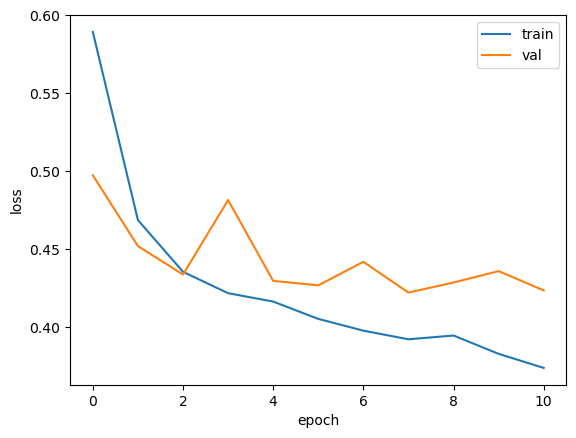

In [ ]:
# 훈련 손실, 검증 손실 그래프 출력

import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

훈련 손실이 잘 줄어들고 있지만     
과대적합을 잘 억제하지 못함     

**Dropout**     
- 과대적합되는 것을 막음    
- simpleRNN, LSTM : dropout, recurrent_dropout 매개변수 가짐      
    dropout : 셀 입력에 적용     
    recurrent_dropout : 순환되는 은닉상태에 드롭아웃 적용 (but 훈련속도가 느려짐)

In [19]:
# LSTM 순환층에 dropout 적용

model_dropout = keras.Sequential()
model_dropout.add(keras.layers.Input(shape=(100,)))
model_dropout.add(keras.layers.Embedding(500, 16))
model_dropout.add(keras.layers.LSTM(8, dropout=0.2))
model_dropout.add(keras.layers.Dense(1, activation='sigmoid'))

20 % 입력을 dropout

In [20]:
# LSTM dropout 모델 훈련하기  

model_dropout.compile(optimizer='adam', loss='binary_crossentropy',metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-simplernn-model.keras',save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
history=model_dropout.fit(train_seq, train_target, epochs=100, batch_size=64, validation_data=(val_seq, val_target), callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.6027 - loss: 0.6460 - val_accuracy: 0.7800 - val_loss: 0.4820
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.7869 - loss: 0.4658 - val_accuracy: 0.7882 - val_loss: 0.4557
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.8030 - loss: 0.4374 - val_accuracy: 0.7964 - val_loss: 0.4424
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.8049 - loss: 0.4250 - val_accuracy: 0.7952 - val_loss: 0.4384
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.8038 - loss: 0.4237 - val_accuracy: 0.7972 - val_loss: 0.4361
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.8072 - loss: 0.4167 - val_accuracy: 0.7968 - val_loss: 0.4465
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.8101 - loss: 0.4122 - val_accuracy: 0.7918 - val_loss: 0.4438
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.8091 - loss: 0.4064 -

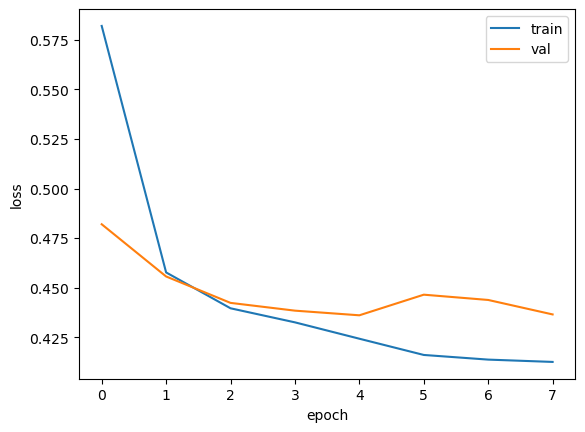

In [21]:
# 훈련 손실, 검증 손실 그래프 출력

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

dropout으로 훈련손실이 줄어드는 것을 조금 억제     
but 검증 손실은 나아지지 않음     

**2개 순환층 LSTM 모델**     
- 2개 중 1개의 순환층은 모든 타임스텝에 대한 은닉 상태를 출력해야함    
-> **return_sequences=True**    



In [ ]:
# 2개 층 LSTM 모델 만들기

model_2lstm = keras.Sequential()
model_2lstm.add(keras.layers.Input(shape=(100,)))
model_2lstm.add(keras.layers.Embedding(500, 16))
model_2lstm.add(keras.layers.LSTM(8, dropout=0.2, return_sequences=True))
model_2lstm.add(keras.layers.LSTM(8, dropout=0.2))
model_2lstm.add(keras.layers.Dense(1, activation='sigmoid'))
model_2lstm.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 100, 8)         │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 8)              │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,353 (36.54 KB)

 Trainable params: 9,353 (36.54 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# LSTM dropout 모델 훈련하기  

model_2lstm.compile(optimizer='adam', loss='binary_crossentropy',metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-2lstm-model.keras',save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
history=model_2lstm.fit(train_seq, train_target, epochs=100, batch_size=64, validation_data=(val_seq, val_target), callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - accuracy: 0.5960 - loss: 0.6484 - val_accuracy: 0.7224 - val_loss: 0.5605
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.7645 - loss: 0.4957 - val_accuracy: 0.7716 - val_loss: 0.4742
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.7831 - loss: 0.4653 - val_accuracy: 0.7864 - val_loss: 0.4530
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - accuracy: 0.7960 - loss: 0.4333 - val_accuracy: 0.7910 - val_loss: 0.4447
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - accuracy: 0.8040 - loss: 0.4290 - val_accuracy: 0.7914 - val_loss: 0.4499
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.8154 - loss: 0.4124 - val_accuracy: 0.7976 - val_loss: 0.4352
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 43ms/step - accuracy: 0.8151 - loss: 0.4106 - val_accuracy: 0.8004 - val_loss: 0.4269
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.8165 - loss: 0

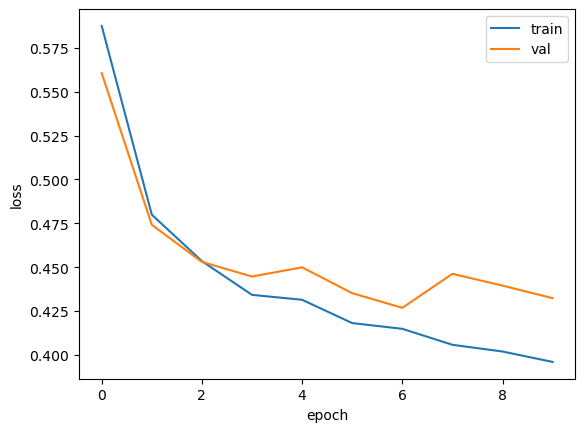

In [24]:
# 훈련 손실, 검증 손실 그래프 출력

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

**GRU Gated Recurrent Unit 셀**     
- LSTM 간소화 버전     
- 셀 상태를 계산하지 않고 은닉 상태 하나만 포함     


In [25]:
# GRU 신경망 모델 만들기

model_gru = keras.Sequential()
model_gru.add(keras.layers.Input(shape=(100,)))
model_gru.add(keras.layers.Embedding(500, 16))
model_gru.add(keras.layers.GRU(8, dropout=0.2))
model_gru.add(keras.layers.Dense(1, activation='sigmoid'))
model_gru.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 8)              │           624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,633 (33.72 KB)

 Trainable params: 8,633 (33.72 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# GRU 신경망 모델 훈련하기 

model_gru.compile(optimizer='adam', loss='binary_crossentropy',metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-gru-model.keras',save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
history=model_gru.fit(train_seq, train_target, epochs=100, batch_size=64, validation_data=(val_seq, val_target), callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.5640 - loss: 0.6695 - val_accuracy: 0.7656 - val_loss: 0.5024
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.7602 - loss: 0.4991 - val_accuracy: 0.7774 - val_loss: 0.4682
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.7856 - loss: 0.4669 - val_accuracy: 0.7858 - val_loss: 0.4570
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.7965 - loss: 0.4479 - val_accuracy: 0.7896 - val_loss: 0.4458
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.7943 - loss: 0.4379 - val_accuracy: 0.7942 - val_loss: 0.4406
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.8070 - loss: 0.4184 - val_accuracy: 0.7876 - val_loss: 0.4554
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.8108 - loss: 0.4136 - val_accuracy: 0.8016 - val_loss: 0.4280
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.8146 - loss: 0.4080 -

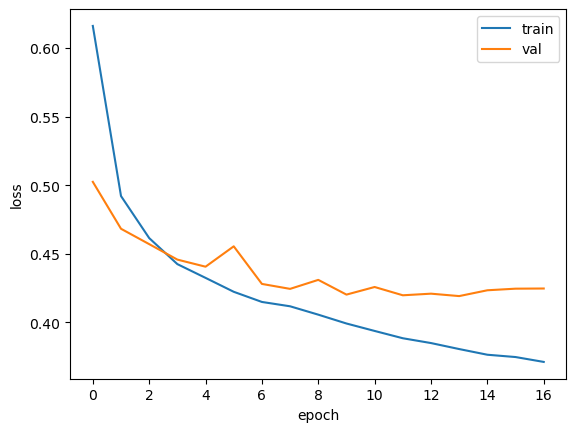

In [27]:
# 훈련 손실, 검증 손실 그래프 출력

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [28]:
# LSTM과 GRU셀로 훈련

test_seq = pad_sequences(test_input, maxlen=100)
best_model = keras.models.load_model('best-gru-model.keras')
best_model.evaluate(test_seq, test_target)

782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.8087 - loss: 0.4142


[0.4142545759677887, 0.8082399964332581]